In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import geopandas as gpd

In [3]:
# dataset 

df = pd.read_csv("C:/Users/ASUS/ERIA_Dataset_2.csv")

In [4]:
df.head(10)

,country_name,country_code,year,gdp_growth_pct,gdp_per_capita,trade_openness_pct,investment_pct_gdp,population_total,gini_index,secure_servers_per_million,corruption_control_score,education_index,income_index,cybersecurity_index,mobile_broadband_traffic_pb,cyber_incident_count,fixed_broadband_subs,secure_servers_per_capita
0,High income,NaN,2014,2.152439,35957.938590,61.919946,21.880012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Low income,NaN,2014,3.074877,771.161463,51.336347,21.320769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Lower middle income,NaN,2014,6.125455,1767.450842,56.089862,28.364959,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Upper middle income,NaN,2014,5.001160,7172.381721,49.044303,35.308260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,High income,NaN,2015,2.343609,36571.192900,60.165665,22.161180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Low income,NaN,2015,-2.102618,736.645564,45.384066,18.692060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Lower middle income,NaN,2015,5.933848,1843.922460,51.459728,28.108411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Upper middle income,NaN,2015,4.521732,7434.595696,45.506394,34.578874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,High income,NaN,2016,1.826359,37014.999540,58.450949,21.977233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Low income,NaN,2016,0.694857,722.757829,46.800476,19.155061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
## filling the missing value

from sklearn.impute import KNNImputer
impute = KNNImputer()

for i in df.select_dtypes(include = "number").columns:
    df[i] = impute.fit_transform(df[[i]])

In [8]:
df.isnull().sum()

country_name                      0
country_code                     44
year                              0
gdp_growth_pct                    0
gdp_per_capita                    0
trade_openness_pct                0
investment_pct_gdp                0
population_total                  0
gini_index                        0
secure_servers_per_million        0
corruption_control_score       1006
education_index                   0
income_index                      0
cybersecurity_index               0
mobile_broadband_traffic_pb       0
cyber_incident_count              0
fixed_broadband_subs              0
secure_servers_per_capita         0
dtype: int64

In [20]:
## drop / remove some columns

workdata = (
    df.drop(df.index[:44])
      .drop(columns = ['corruption_control_score', 'country_code', 'gini_index', 'investment_pct_gdp'])
      .rename(columns = {'gdp_growth_pct': 'GDP Growth',
                         'gdp_per_capita': "GDP per Capita",
                         'trade_openness_pct': 'Trade Opennes',
                         'population_total': 'Population Total',
                         'secure_servers_per_million': 'Secure Servers per Million',
                         'education_index': 'Education Index',
                         'income_index': 'Income Index',
                         'cybersecurity_index': 'Cybersecurity Index',
                         'mobile_broadband_traffic_pb': 'Mobile Broadband Traffic',
                         'cyber_incident_count': 'Cyber Incident Count',
                         'fixed_broadband_subs': 'Fixed Broadband Subs',
                         'secure_servers_per_capita': 'Secure Servers per Capita',
                         'country_name': 'Country'})
      .reset_index(drop =True)
)

In [21]:
workdata.head(20)

,Country,year,GDP Growth,GDP per Capita,Trade Opennes,Population Total,Secure Servers per Million,Education Index,Income Index,Cybersecurity Index,Mobile Broadband Traffic,Cyber Incident Count,Fixed Broadband Subs,Secure Servers per Capita
0,Aruba,2014.0,-1.586575,27914.843340,162.882052,106807.0,552.398251,0.661865,0.709481,50.397965,115.146555,17.076642,18.573500,0.000552
1,Aruba,2015.0,-0.623626,27458.225330,145.833663,107906.0,732.118696,0.661865,0.709481,50.397965,115.146555,17.076642,18.237000,0.000732
2,Aruba,2016.0,1.719625,27719.500730,142.239763,108727.0,1131.273741,0.661865,0.709481,50.397965,115.146555,17.076642,15.646083,0.001131
3,Aruba,2017.0,7.048533,29671.135830,143.804295,108735.0,947.257093,0.661865,0.709481,50.397965,115.146555,17.076642,15.646083,0.000947
4,Aruba,2018.0,2.397086,30334.116220,145.213552,108908.0,1120.211555,0.661865,0.709481,50.397965,115.146555,17.076642,15.646083,0.001120
5,Aruba,2019.0,-2.232442,29576.809710,145.343573,109203.0,1364.431380,0.661865,0.709481,50.397965,115.146555,17.076642,17.744400,0.001364
6,Aruba,2020.0,-26.211820,21947.995330,124.137267,108587.0,1556.355733,0.661865,0.709481,50.397965,115.146555,17.076642,17.690900,0.001556
7,Aruba,2021.0,24.132627,27469.005620,147.015577,107700.0,1643.454039,0.661865,0.709481,50.397965,115.146555,17.076642,17.664900,0.001643
8,Aruba,2022.0,8.517918,29917.128030,172.884172,107310.0,1621.470506,0.661865,0.709481,50.397965,115.146555,17.076642,17.486200,0.001621
9,Aruba,2023.0,4.263719,31178.473680,169.798283,107359.0,1397.181419,0.661865,0.709481,50.397965,115.146555,17.076642,15.646083,0.001397


In [22]:
## see the country anme listed

workdata["Country"].unique()

array(['Aruba', 'Africa Eastern and Southern', 'Afghanistan',
       'Africa Western and Central', 'Angola', 'Albania', 'Andorra',
       'Arab World', 'United Arab Emirates', 'Argentina', 'Armenia',
       'American Samoa', 'Antigua and Barbuda', 'Australia', 'Austria',
       'Azerbaijan', 'Burundi', 'Belgium', 'Benin', 'Burkina Faso',
       'Bangladesh', 'Bulgaria', 'Bahrain', 'Bahamas, The',
       'Bosnia and Herzegovina', 'Belarus', 'Belize', 'Bermuda',
       'Bolivia', 'Brazil', 'Barbados', 'Brunei Darussalam', 'Bhutan',
       'Botswana', 'Central African Republic', 'Canada',
       'Central Europe and the Baltics', 'Switzerland', 'Channel Islands',
       'Chile', 'China', "Cote d'Ivoire", 'Cameroon', 'Congo, Dem. Rep.',
       'Congo, Rep.', 'Colombia', 'Comoros', 'Cabo Verde', 'Costa Rica',
       'Caribbean small states', 'Cuba', 'Curacao', 'Cayman Islands',
       'Cyprus', 'Czechia', 'Germany', 'Djibouti', 'Dominica', 'Denmark',
       'Dominican Republic', 'Algeria',
 

In [23]:
## filter to only 2024 for geopandas

latam_2024 = workdata[workdata['year'] == 2024].copy()

In [24]:
## filter only latam countries

latam_countries = [
    'Argentina','Bolivia','Brazil','Chile','Colombia','Costa Rica','Ecuador',
    'El Salvador','Guatemala','Guyana','Honduras','Mexico','Nicaragua',
    'Panama','Paraguay','Peru','Suriname','Uruguay','Venezuela, RB'
]

latam_2024 = latam_2024[latam_2024['Country'].isin(latam_countries)]

In [45]:
latam_2024.head(25)

,Country,year,GDP Growth,GDP per Capita,Trade Opennes,Population Total,Secure Servers per Million,Education Index,Income Index,Cybersecurity Index,Mobile Broadband Traffic,Cyber Incident Count,Fixed Broadband Subs,Secure Servers per Capita
107,Argentina,2024.0,-1.719105,12667.031370,28.159401,45696159.0,5453.434281,0.661865,0.709481,51.5,115.146555,4.000000,26.097600,0.005453
314,Bolivia,2024.0,1.384683,3226.188076,85.880548,12413315.0,364.447370,0.661865,0.709481,43.2,0.009684,17.076642,12.071100,0.000364
325,Brazil,2024.0,3.395866,9564.576077,35.531220,211998573.0,6941.174080,0.661865,0.709481,96.5,52.260900,1.000000,24.079200,0.006941
433,Chile,2024.0,2.644312,14579.400110,63.859857,19764771.0,11912.609560,0.661865,0.709481,70.2,301.807000,1.000000,23.731400,0.011913
499,Colombia,2024.0,1.743801,6873.423024,36.888693,52886363.0,1126.207147,0.661865,0.709481,65.7,105.980000,1.000000,17.224400,0.001126
532,Costa Rica,2024.0,4.321224,14866.582370,71.331014,5129910.0,1999.840153,0.661865,0.709481,75.1,89.811000,1.000000,23.287700,0.002000
727,Ecuador,2024.0,-2.001255,5999.393911,57.203140,18135478.0,490.861063,0.661865,0.709481,87.1,77.545000,1.000000,17.246400,0.000491
989,Guatemala,2024.0,3.651865,4563.095765,47.344195,18406359.0,109.147062,0.661865,0.709481,40.0,115.146555,17.076642,5.337920,0.000109
1009,Guyana,2024.0,43.372009,32932.213580,85.880548,831087.0,175.673546,0.661865,0.709481,47.4,115.146555,17.076642,15.646083,0.000176
1031,Honduras,2024.0,3.553970,2573.371600,91.110159,10825703.0,148.812507,0.661865,0.709481,28.1,145.749000,17.076642,4.579150,0.000149


In [ ]:
### Econ indicators ###

In [26]:
## load the geometry

import geopandas as gpd

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

In [41]:
## merge the data

latam_2024["Country"] = latam_2024["Country"].replace({'Venezuela, RB': 'Venezuela'})

latam_map = world.merge(
    latam_2024,
    left_on = "ADMIN",
    right_on = "Country",
    how = "left"
)

In [43]:
## define the LATAM bounding box

latam_bounds = (-120, -60, -30, 35)

latam_map_clipped = latam_map.cx[
    latam_bounds[0]: latam_bounds[2],
    latam_bounds[1]: latam_bounds[3]   
]

In [44]:
## checking venezuela

latam_map_clipped.loc[
    latam_map_clipped["ADMIN"] == "Venezuela",
    ["GDP Growth", "Population Total", "GDP per Capita", "Income Index"]
]

,GDP Growth,Population Total,GDP per Capita,Income Index
40,NaN,NaN,NaN,NaN


In [36]:
print(latam_map_clipped["ADMIN"].unique())

['Argentina' 'Chile' 'Mexico' 'Uruguay' 'Brazil' 'Bolivia' 'Peru'
 'Colombia' 'Panama' 'Costa Rica' 'Nicaragua' 'Honduras' 'El Salvador'
 'Guatemala' 'Guyana' 'Suriname' 'Ecuador' 'Paraguay']


In [37]:
print(latam_map["ADMIN"].unique())

['Argentina' 'Chile' 'Mexico' 'Uruguay' 'Brazil' 'Bolivia' 'Peru'
 'Colombia' 'Panama' 'Costa Rica' 'Nicaragua' 'Honduras' 'El Salvador'
 'Guatemala' 'Guyana' 'Suriname' 'Ecuador' 'Paraguay']


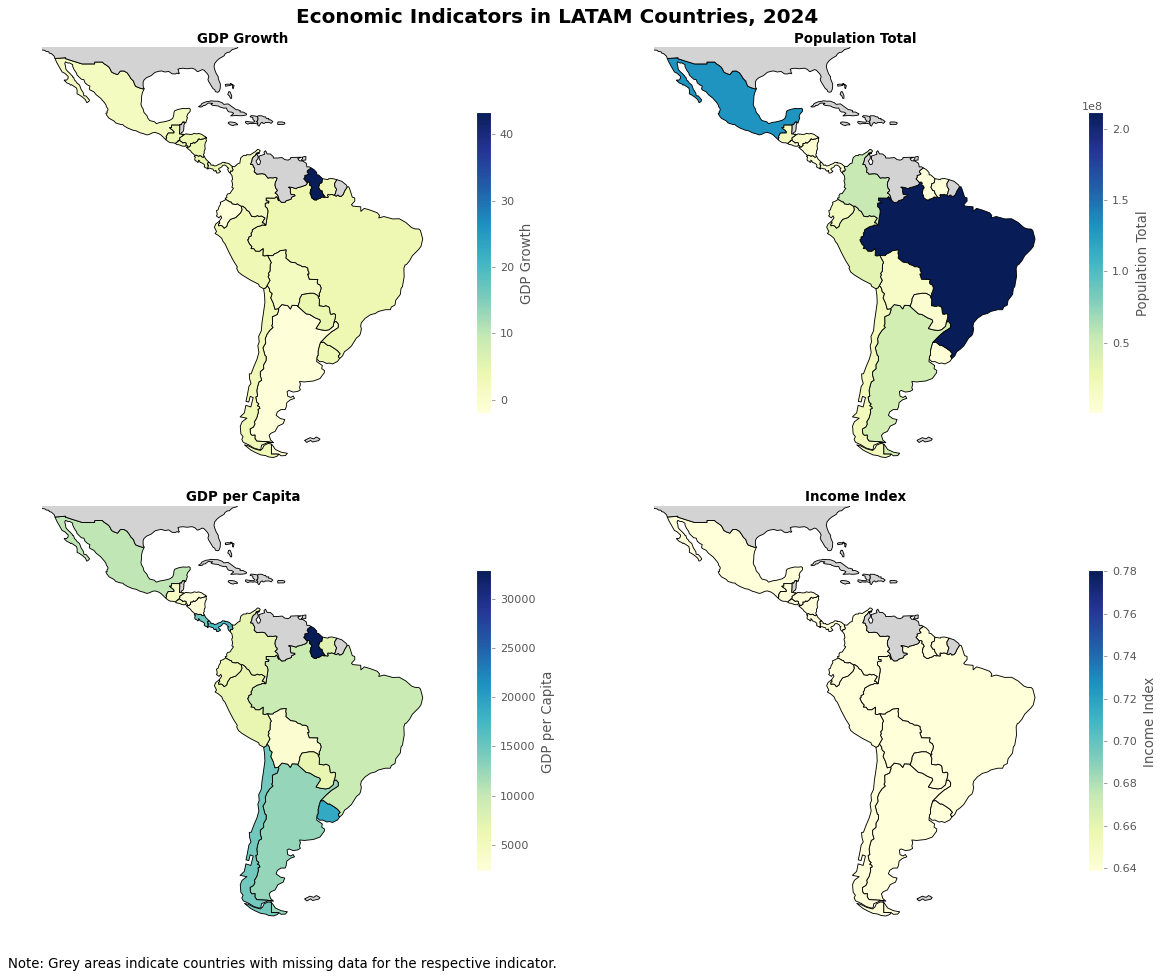

In [66]:
## plot latam geomaps

plt.style.use("ggplot")

fig, axes = plt.subplots(2, 2, figsize = (16, 12))

indicators = [
    "GDP Growth",
    "Population Total",
    "GDP per Capita",
    "Income Index"
]

for ax, indicator in zip(axes.flatten(), indicators):
    
    latam_map_clipped.plot(
        column = indicator,
        cmap = "YlGnBu",
        linewidth = 0.8,
        edgecolor = "black",
        legend = True,
        missing_kwds = {
            "color": 'lightgrey',
            'label': 'Missing data'
        },
        legend_kwds = {
            "shrink": 0.7,
            "label": indicator
        },
        ax = ax
    )
    
    ax.set_title(indicator, fontsize = 12, fontweight = 'bold')
    ax.set_xlim(-120, -30),
    ax.set_ylim(-60, 35)
    ax.axis('off')
    
plt.suptitle(
    "Economic Indicators in LATAM Countries, 2024",
    fontsize = 18,
    fontweight = 'bold'
)

plt.subplots_adjust(hspace = 0.25, wspace = 0.15)

fig.text(
    0.5, -0.02, 
    "Note: Grey areas indicate countries with missing data for the respective indicator.",
    fontsize = 12,
    ha = 'right'
)

plt.tight_layout()
plt.show()